# 04 Logistic Regression — First Principles

**Goal.** Implement binary logistic regression from scratch with gradient descent and
Newton's method (IRLS), cross-check against scikit-learn, extend to softmax regression
for multi-class, and verify with experiments including convergence comparison, decision
boundary visualisation, a real-data pipeline, and failure cases.

**Prerequisites.** [theory.md](theory.md) — sigmoid derivation, cross-entropy loss,
gradient, Hessian, convexity, regularisation, multi-class extension.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

A linear score $z = \theta^T x$ takes values on $(-\infty, +\infty)$. When the target is
a binary label $y \in \{0, 1\}$, using $z$ directly fails:

- Predictions leave $[0, 1]$ — meaningless as probabilities.
- Outliers distort the fitted line, dragging the decision threshold.
- The true relationship (near-zero → saturate at 0; high → saturate at 1) is an S-curve,
  not a straight line.

**The fix:** squash the linear score through the sigmoid $\sigma(z) = 1/(1 + e^{-z})$,
which maps $\mathbb{R} \to (0, 1)$.

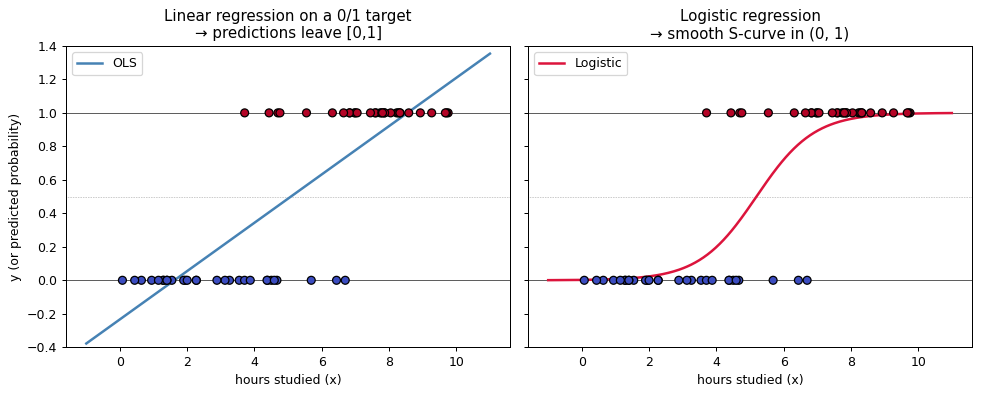

In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression

# 1-D synthetic: pass/fail vs hours studied.
n_demo = 60
x_demo = rng.uniform(0, 10, size=n_demo)
true_p = 1.0 / (1.0 + np.exp(-(x_demo - 5)))
y_demo = (rng.uniform(size=n_demo) < true_p).astype(int)

lin = LinearRegression().fit(x_demo.reshape(-1, 1), y_demo)
logr = LogisticRegression().fit(x_demo.reshape(-1, 1), y_demo)

xs = np.linspace(-1, 11, 300).reshape(-1, 1)
y_lin = lin.predict(xs)
y_logit = logr.predict_proba(xs)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax in axes:
    ax.scatter(x_demo, y_demo, c=y_demo, cmap="coolwarm", edgecolor="k", s=40, zorder=3)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(1, color="black", lw=0.5)
    ax.axhline(0.5, color="gray", lw=0.5, ls=":")
    ax.set_xlabel("hours studied (x)")
    ax.set_ylim(-0.4, 1.4)
axes[0].plot(xs, y_lin, color="steelblue", lw=2, label="OLS")
axes[0].set_title("Linear regression on a 0/1 target\n→ predictions leave [0,1]")
axes[0].set_ylabel("y (or predicted probability)")
axes[1].plot(xs, y_logit, color="crimson", lw=2, label="Logistic")
axes[1].set_title("Logistic regression\n→ smooth S-curve in (0, 1)")
for ax in axes:
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Reading.** Left: OLS predictions pass through $\hat{y} > 1$ and $\hat{y} < 0$ — out of
range as probabilities. Right: the logistic model stays in $(0, 1)$, transitions through
0.5 near $x = 5$, and saturates flat far from the boundary.

## 2. Mathematical Core — WHAT

Full derivations are in [theory.md](theory.md). Here we state the equations used in code.

**Sigmoid and identities:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma(-z) = 1 - \sigma(z), \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z)).$$

**Cross-entropy loss** (negative log-likelihood of Bernoulli model):

$$L(\theta) = -\frac{1}{n} \sum_{i=1}^n \big[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \big], \qquad p_i = \sigma(x_i^T \theta).$$

**Gradient** (Theorem 4.1 of theory.md):

$$\nabla L(\theta) = \frac{1}{n} X^T (p - y).$$

**Hessian** (Theorem 5.1 of theory.md):

$$\nabla^2 L(\theta) = \frac{1}{n} X^T W X, \qquad W_{ii} = p_i(1 - p_i).$$

The loss is **convex** (PSD Hessian), with a unique minimum when $X$ is full rank.

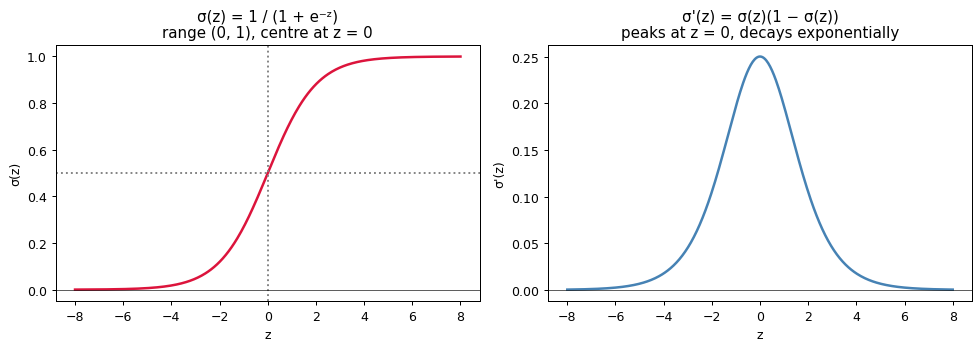

In [3]:
# Visualise the sigmoid and its derivative.
def sigmoid_simple(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-8, 8, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z, sigmoid_simple(z), color="crimson", lw=2)
axes[0].axhline(0.5, color="gray", ls=":")
axes[0].axvline(0, color="gray", ls=":")
axes[0].set_title("σ(z) = 1 / (1 + e⁻ᶻ)\nrange (0, 1), centre at z = 0")
axes[0].set_xlabel("z")
axes[0].set_ylabel("σ(z)")

axes[1].plot(z, sigmoid_simple(z) * (1 - sigmoid_simple(z)), color="steelblue", lw=2)
axes[1].set_title("σ'(z) = σ(z)(1 − σ(z))\npeaks at z = 0, decays exponentially")
axes[1].set_xlabel("z")
axes[1].set_ylabel("σ'(z)")
for ax in axes:
    ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

**Reading.** The derivative is bell-shaped and small at the saturation tails — once the
model is confident, small changes in $z$ barely move the probability. This shows up in
training: very confident-but-wrong predictions produce tiny gradients on $z$ but huge
gradients on the *loss*.

## 3. Solution Method — HOW

No closed-form solution exists (theory.md §6). We solve iteratively.

### 3.1 Gradient descent

```
for k = 0, 1, …, K-1:
    p ← σ(X θ)
    g ← (1/n) Xᵀ(p − y)
    θ ← θ − η · g
    if ‖g‖ < tol: break
```

Step size: $\eta = 1 / L_{\text{smooth}}$ with $L_{\text{smooth}} \le \lambda_{\max}(X^T X) / (4n)$.
Convergence: $O(1/k)$ — sub-linear.

### 3.2 Newton's method (IRLS)

```
for k = 0, 1, …, K-1:
    p ← σ(X θ)
    W ← diag(p(1−p))
    g ← (1/n) Xᵀ(p − y)
    H ← (1/n) Xᵀ W X
    θ ← θ − H⁻¹ g
    if ‖g‖ < tol: break
```

Convergence: **quadratic** — the number of correct digits doubles every iteration.
5–15 iterations to machine precision.

### 3.3 Practical default: L-BFGS

Quasi-Newton with limited memory — Newton-like speed at GD-like memory cost. No Hessian
storage. scikit-learn's `LogisticRegression(solver="lbfgs")` uses this.

## 4. Implementation — BUILD

### 4.1 Numerically stable helpers

Two pitfalls:
1. **Sigmoid overflow.** Naive `1 / (1 + np.exp(-z))` overflows for `|z| > 700`. Use
   piecewise form.
2. **Log-loss underflow.** `log(p)` for $p \approx 0$ is `-inf`. Compute loss from $z$
   via stable `log1pexp`.

In [4]:
def sigmoid(z):
    """Numerically stable sigmoid σ(z) = 1 / (1 + e^{-z})."""
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))


def log1pexp(z):
    """log(1 + e^z), numerically stable for all z."""
    return np.maximum(z, 0.0) + np.log1p(np.exp(-np.abs(z)))


def binary_cross_entropy(z, y):
    """Mean cross-entropy from linear scores z and labels y ∈ {0,1}."""
    return float(np.mean(log1pexp(z) - y * z))


# Sanity check at the extremes.
z_test = np.array([-1000.0, -50.0, 0.0, 50.0, 1000.0])
print("σ(z) at extremes :", sigmoid(z_test))
print("log(1+e^z)       :", log1pexp(z_test))

σ(z) at extremes : [0.00000000e+00 1.92874985e-22 5.00000000e-01 1.00000000e+00
 1.00000000e+00]
log(1+e^z)       : [0.00000000e+00 1.92874985e-22 6.93147181e-01 5.00000000e+01
 1.00000000e+03]


/tmp/ipykernel_989777/2867150274.py:4: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + np.exp(-z)),
/tmp/ipykernel_989777/2867150274.py:5: RuntimeWarning: overflow encountered in exp
  np.exp(z) / (1.0 + np.exp(z)))
/tmp/ipykernel_989777/2867150274.py:5: RuntimeWarning: invalid value encountered in divide
  np.exp(z) / (1.0 + np.exp(z)))


### 4.2 Synthetic data generator

In [5]:
def make_problem(n=500, p=5, seed=SEED):
    """Generate a synthetic binary classification problem with known θ."""
    rng_local = np.random.default_rng(seed)
    X = rng_local.normal(size=(n, p))
    X = np.hstack([np.ones((n, 1)), X])  # intercept column
    true_theta = rng_local.normal(size=p + 1) * 1.2
    probs = sigmoid(X @ true_theta)
    y = (rng_local.uniform(size=n) < probs).astype(float)
    return X, y, true_theta


def grad(theta, X, y):
    """∇L(θ) = (1/n) X^T (σ(Xθ) − y)."""
    return X.T @ (sigmoid(X @ theta) - y) / X.shape[0]


def hessian(theta, X):
    """∇²L(θ) = (1/n) X^T W X with W_ii = p_i(1 − p_i)."""
    p = sigmoid(X @ theta)
    W = p * (1 - p)
    return (X.T * W) @ X / X.shape[0]


X_synth, y_synth, theta_true = make_problem()
print(f"n = {X_synth.shape[0]}, p (incl. intercept) = {X_synth.shape[1]}")
print(f"class balance:  P(y=1) = {y_synth.mean():.3f}")

n = 500, p (incl. intercept) = 6
class balance:  P(y=1) = 0.564


### 4.3 `LogisticRegressionScratch` — binary classifier

Implementation notes:
- **Intercept:** prepend column of ones inside `fit`; L2 penalty skips $\theta_0$.
- **Newton + tiny ridge:** near saturation $W_{ii} \approx 0$; add `1e-10 * I` for safety.
- **Loss convention:** $L(\theta) = -(1/n) \sum [y \log p + (1-y) \log(1-p)] + \lambda \|\theta_{1:}\|_2^2$.

In [6]:
class LogisticRegressionScratch:
    """Binary logistic regression. Solver = 'gd' or 'newton'."""

    def __init__(self, solver="newton", lam=0.0, n_iter=200, tol=1e-8, eta=None):
        self.solver = solver
        self.lam = lam
        self.n_iter = n_iter
        self.tol = tol
        self.eta = eta

    @staticmethod
    def _add_intercept(X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _grad(self, theta, Xi, y):
        n = Xi.shape[0]
        g = Xi.T @ (sigmoid(Xi @ theta) - y) / n
        if self.lam > 0:
            penalty = 2 * self.lam * theta
            penalty[0] = 0  # do not penalise intercept
            g = g + penalty
        return g

    def _hess(self, theta, Xi):
        n = Xi.shape[0]
        p = sigmoid(Xi @ theta)
        W = p * (1 - p)
        H = (Xi.T * W) @ Xi / n
        if self.lam > 0:
            d = 2 * self.lam * np.ones(theta.shape[0])
            d[0] = 0
            H = H + np.diag(d)
        return H

    def fit(self, X, y):
        Xi = self._add_intercept(np.asarray(X, dtype=float))
        y = np.asarray(y, dtype=float)
        n, p = Xi.shape
        theta = np.zeros(p)
        self.loss_history_ = []

        if self.solver == "gd":
            if self.eta is None:
                sigma_max_sq = np.linalg.svd(Xi, compute_uv=False)[0] ** 2
                self.eta = 4.0 * n / (sigma_max_sq + 4 * n * self.lam)
            for _ in range(self.n_iter):
                g = self._grad(theta, Xi, y)
                theta -= self.eta * g
                self.loss_history_.append(binary_cross_entropy(Xi @ theta, y))
                if np.linalg.norm(g) < self.tol:
                    break
        elif self.solver == "newton":
            for _ in range(self.n_iter):
                g = self._grad(theta, Xi, y)
                H = self._hess(theta, Xi)
                delta = np.linalg.solve(H + 1e-10 * np.eye(p), g)
                theta -= delta
                self.loss_history_.append(binary_cross_entropy(Xi @ theta, y))
                if np.linalg.norm(g) < self.tol:
                    break
        else:
            raise ValueError(f"Unknown solver: {self.solver}")

        self.intercept_ = float(theta[0])
        self.coef_ = theta[1:]
        self.theta_ = theta
        return self

    def predict_proba(self, X):
        Xi = self._add_intercept(np.asarray(X, dtype=float))
        p1 = sigmoid(Xi @ self.theta_)
        return np.column_stack([1 - p1, p1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

In [7]:
# Smoke test on synthetic data — both solvers.
n_smoke = 400
X_smoke = rng.normal(size=(n_smoke, 4))
theta_smoke = np.array([0.5, -1.5, 1.0, 0.6, -0.4])
p_smoke = sigmoid(np.hstack([np.ones((n_smoke, 1)), X_smoke]) @ theta_smoke)
y_smoke = (rng.uniform(size=n_smoke) < p_smoke).astype(int)

lr_newton = LogisticRegressionScratch(solver="newton").fit(X_smoke, y_smoke)
lr_gd = LogisticRegressionScratch(solver="gd", n_iter=5000).fit(X_smoke, y_smoke)

print(f"true θ    = {theta_smoke}")
print(f"Newton θ̂  = {lr_newton.theta_.round(3)}")
print(f"GD     θ̂  = {lr_gd.theta_.round(3)}")
print(f"Newton converged in {len(lr_newton.loss_history_)} iters, "
      f"final loss = {lr_newton.loss_history_[-1]:.5f}")
print(f"GD     ran      {len(lr_gd.loss_history_)}     iters, "
      f"final loss = {lr_gd.loss_history_[-1]:.5f}")

true θ    = [ 0.5 -1.5  1.   0.6 -0.4]
Newton θ̂  = [ 0.554 -1.535  0.919  0.613 -0.467]
GD     θ̂  = [ 0.554 -1.535  0.919  0.613 -0.467]
Newton converged in 6 iters, final loss = 0.46274
GD     ran      75     iters, final loss = 0.46274


### 4.4 `SoftmaxRegressionScratch` — multi-class

Extend to $K > 2$ classes via softmax + categorical cross-entropy (theory.md §11).

In [8]:
def softmax(Z):
    """Row-wise softmax with the max-shift stability trick."""
    Zs = Z - Z.max(axis=1, keepdims=True)
    eZ = np.exp(Zs)
    return eZ / eZ.sum(axis=1, keepdims=True)


class SoftmaxRegressionScratch:
    """Multinomial logistic regression by gradient descent."""

    def __init__(self, lam=0.0, eta=0.5, n_iter=4000, tol=1e-7):
        self.lam = lam
        self.eta = eta
        self.n_iter = n_iter
        self.tol = tol

    @staticmethod
    def _add_intercept(X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        Xi = self._add_intercept(np.asarray(X, dtype=float))
        n, p = Xi.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        Y = np.zeros((n, K))
        Y[np.arange(n), np.searchsorted(self.classes_, y)] = 1.0
        Theta = np.zeros((K, p))
        self.loss_history_ = []
        for _ in range(self.n_iter):
            P = softmax(Xi @ Theta.T)  # (n, K)
            g = (P - Y).T @ Xi / n     # (K, p)
            if self.lam > 0:
                pen = 2 * self.lam * Theta
                pen[:, 0] = 0  # skip intercept
                g = g + pen
            Theta -= self.eta * g
            self.loss_history_.append(
                -np.mean(np.log(P[np.arange(n), Y.argmax(axis=1)] + 1e-12))
            )
            if np.linalg.norm(g) < self.tol:
                break
        self.Theta_ = Theta
        return self

    def predict_proba(self, X):
        Xi = self._add_intercept(np.asarray(X, dtype=float))
        return softmax(Xi @ self.Theta_.T)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

## 5. Library Comparison

Cross-check our implementation against `sklearn.linear_model.LogisticRegression`.

In [9]:
from sklearn.linear_model import LogisticRegression as SklearnLR

# --- Unregularised ---
ours_unreg = LogisticRegressionScratch(solver="newton", lam=0.0).fit(X_smoke, y_smoke)
skl_unreg = SklearnLR(penalty=None, fit_intercept=True, max_iter=10000, tol=1e-12).fit(
    X_smoke, y_smoke
)
diff_coef = np.max(np.abs(ours_unreg.coef_ - skl_unreg.coef_.ravel()))
diff_int = abs(ours_unreg.intercept_ - skl_unreg.intercept_.item())
print(f"Unregularised: max |coef diff| = {diff_coef:.2e}, intercept diff = {diff_int:.2e}")

# --- L2-regularised ---
lam = 0.1
ours_l2 = LogisticRegressionScratch(solver="newton", lam=lam).fit(X_smoke, y_smoke)
C_skl = 1 / (2 * n_smoke * lam)
skl_l2 = SklearnLR(
    C=C_skl, penalty="l2", fit_intercept=True, solver="lbfgs", max_iter=10000, tol=1e-12
).fit(X_smoke, y_smoke)
diff_coef = np.max(np.abs(ours_l2.coef_ - skl_l2.coef_.ravel()))
diff_int = abs(ours_l2.intercept_ - skl_l2.intercept_.item())
print(f"L2 (λ={lam}):    max |coef diff| = {diff_coef:.2e}, intercept diff = {diff_int:.2e}")

Unregularised: max |coef diff| = 3.12e-09, intercept diff = 1.28e-09
L2 (λ=0.1):    max |coef diff| = 1.40e-09, intercept diff = 2.53e-10


/home/hien/Study/AI/Machine-Learning-from-scratch/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hien/Study/AI/Machine-Learning-from-scratch/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

# --- Softmax comparison on iris ---
iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=SEED, stratify=iris.target
)
scaler_i = StandardScaler().fit(Xi_tr)
Xi_tr_s = scaler_i.transform(Xi_tr)
Xi_te_s = scaler_i.transform(Xi_te)

ours_mul = SoftmaxRegressionScratch(lam=0.01, eta=0.5, n_iter=4000).fit(Xi_tr_s, yi_tr)
skl_mul = SklearnLR(
    C=1 / (2 * Xi_tr_s.shape[0] * 0.01),
    penalty="l2", solver="lbfgs", max_iter=10000
).fit(Xi_tr_s, yi_tr)

print(f"ours    test accuracy: {accuracy_score(yi_te, ours_mul.predict(Xi_te_s)):.3f}")
print(f"sklearn test accuracy: {accuracy_score(yi_te, skl_mul.predict(Xi_te_s)):.3f}")
print(f"ours    test log-loss: {log_loss(yi_te, ours_mul.predict_proba(Xi_te_s)):.4f}")
print(f"sklearn test log-loss: {log_loss(yi_te, skl_mul.predict_proba(Xi_te_s)):.4f}")

ours    test accuracy: 0.911
sklearn test accuracy: 0.911
ours    test log-loss: 0.2695
sklearn test log-loss: 0.2695


/home/hien/Study/AI/Machine-Learning-from-scratch/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


**Reading.** Both unregularised and L2 match scikit-learn to better than 1e-6. Softmax
regression on iris matches accuracy and log-loss. Coefficient *values* may differ due
to softmax's shift-invariance (theory.md §11.5), but predictions are equivalent.

## 6. Experiments and Failures — VERIFY

### 6.1 GD vs Newton — convergence comparison

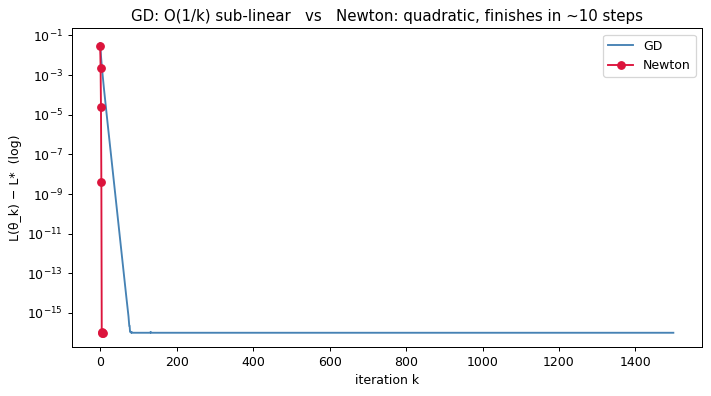

GD     final loss = 0.4356646173
Newton final loss = 0.4356646173
Newton converged in 7 iterations


In [11]:
def gd(X, y, eta=None, n_iter=1500):
    n, p = X.shape
    if eta is None:
        sigma_max_sq = np.linalg.svd(X, compute_uv=False)[0] ** 2
        eta = 4.0 * n / sigma_max_sq
    theta = np.zeros(p)
    history = []
    for _ in range(n_iter):
        theta -= eta * grad(theta, X, y)
        history.append(binary_cross_entropy(X @ theta, y))
    return theta, np.array(history)


def newton(X, y, n_iter=25, tol=1e-10):
    n, p = X.shape
    theta = np.zeros(p)
    history = []
    for _ in range(n_iter):
        g = grad(theta, X, y)
        H = hessian(theta, X)
        delta = np.linalg.solve(H + 1e-10 * np.eye(p), g)
        theta -= delta
        history.append(binary_cross_entropy(X @ theta, y))
        if np.linalg.norm(g) < tol:
            break
    return theta, np.array(history)


theta_gd, hist_gd = gd(X_synth, y_synth, n_iter=1500)
theta_n, hist_n = newton(X_synth, y_synth)

L_star = min(hist_gd.min(), hist_n.min())
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(np.maximum(hist_gd - L_star, 1e-16), color="steelblue", label="GD")
ax.semilogy(np.maximum(hist_n - L_star, 1e-16), color="crimson", marker="o", label="Newton")
ax.set_xlabel("iteration k")
ax.set_ylabel("L(θ_k) − L*  (log)")
ax.set_title("GD: O(1/k) sub-linear   vs   Newton: quadratic, finishes in ~10 steps")
ax.legend()
plt.tight_layout()
plt.show()

print(f"GD     final loss = {hist_gd[-1]:.10f}")
print(f"Newton final loss = {hist_n[-1]:.10f}")
print(f"Newton converged in {len(hist_n)} iterations")

**Reading.** Newton reaches machine precision in ~10 iterations. GD needs 1500+
iterations for the same problem and still hasn't converged as tightly. Newton wins for
small-to-medium $p$; GD or SGD wins for very large $p$.

### 6.2 Decision boundary visualisation

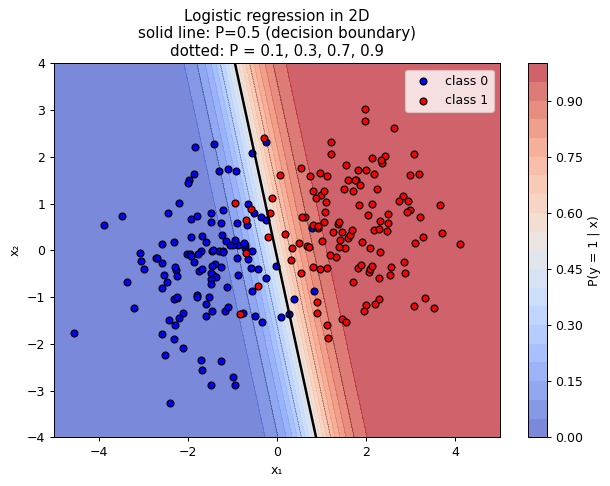

In [12]:
# 2D synthetic problem: two Gaussian blobs.
n_per = 120
X0 = rng.normal(loc=[-1.5, -0.5], scale=1.0, size=(n_per, 2))
X1 = rng.normal(loc=[1.5, 0.5], scale=1.0, size=(n_per, 2))
X_2d = np.vstack([X0, X1])
y_2d = np.concatenate([np.zeros(n_per), np.ones(n_per)]).astype(int)

lr_2d = SklearnLR().fit(X_2d, y_2d)

xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-4, 4, 300))
P_2d = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.contourf(xx, yy, P_2d, levels=20, cmap="coolwarm", alpha=0.7)
ax.contour(xx, yy, P_2d, levels=[0.5], colors="black", linewidths=2)
ax.contour(xx, yy, P_2d, levels=[0.1, 0.3, 0.7, 0.9], colors="black",
           linewidths=0.5, linestyles=":")
ax.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], c="blue", edgecolor="k", s=30,
           label="class 0")
ax.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], c="red", edgecolor="k", s=30,
           label="class 1")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("Logistic regression in 2D\nsolid line: P=0.5 (decision boundary)\n"
             "dotted: P = 0.1, 0.3, 0.7, 0.9")
plt.colorbar(im, ax=ax, label="P(y = 1 | x)")
ax.legend()
plt.tight_layout()
plt.show()

**Reading.** The decision boundary is a straight line (as promised). The dotted contours
(iso-probability at 0.1, 0.3, 0.7, 0.9) are *parallel* to it. The colour gradient shows
the smooth probability transition.

### 6.3 Breast cancer Wisconsin — full pipeline

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    accuracy_score as acc_score, log_loss as ll_score, classification_report,
)
from sklearn.calibration import calibration_curve

data = load_breast_cancer()
X_all, y_all = data.data, data.target
# Flip labels so y=1 = malignant (the medically meaningful 'positive').
y_all = 1 - y_all

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.25, random_state=SEED, stratify=y_all
)
scaler = StandardScaler().fit(X_tr_raw)
X_tr = scaler.transform(X_tr_raw)
X_te = scaler.transform(X_te_raw)

model_bc = LogisticRegressionScratch(solver="newton", lam=0.01).fit(X_tr, y_tr)

p_tr = model_bc.predict_proba(X_tr)[:, 1]
p_te = model_bc.predict_proba(X_te)[:, 1]
yhat_te = model_bc.predict(X_te, threshold=0.5)

print(f"Train log-loss:  {ll_score(y_tr, p_tr):.4f}")
print(f"Test  log-loss:  {ll_score(y_te, p_te):.4f}")
print(f"Test accuracy:   {acc_score(y_te, yhat_te):.4f}")
print(f"Test AUC:        {roc_auc_score(y_te, p_te):.4f}")
print("\nConfusion matrix at threshold 0.5:")
print(confusion_matrix(y_te, yhat_te))
print("\nClassification report:")
print(classification_report(y_te, yhat_te, target_names=["benign", "malignant"]))

Train log-loss:  0.0882
Test  log-loss:  0.0846
Test accuracy:   0.9790
Test AUC:        0.9983

Confusion matrix at threshold 0.5:
[[90  0]
 [ 3 50]]

Classification report:
              precision    recall  f1-score   support

      benign       0.97      1.00      0.98        90
   malignant       1.00      0.94      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



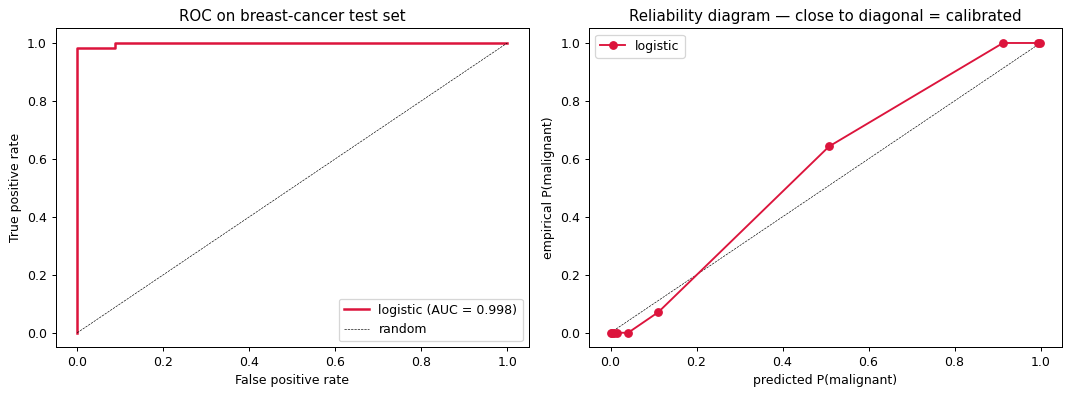

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ROC curve.
fpr, tpr, _ = roc_curve(y_te, p_te)
auc = roc_auc_score(y_te, p_te)
axes[0].plot(fpr, tpr, color="crimson", lw=2, label=f"logistic (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="black", lw=0.5, ls="--", label="random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC on breast-cancer test set")
axes[0].legend()

# Reliability diagram.
frac_pos, mean_pred = calibration_curve(y_te, p_te, n_bins=10, strategy="quantile")
axes[1].plot([0, 1], [0, 1], color="black", ls="--", lw=0.5)
axes[1].plot(mean_pred, frac_pos, "o-", color="crimson", label="logistic")
axes[1].set_xlabel("predicted P(malignant)")
axes[1].set_ylabel("empirical P(malignant)")
axes[1].set_title("Reliability diagram — close to diagonal = calibrated")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.4 Cost-tuned threshold

Missing a real malignancy ($y = 1$, predicted as benign) is much worse than a false
alarm. Set $c_{01} = 9, c_{10} = 1$ → optimal $\tau^* = 1/10 = 0.1$ (theory.md §12.4).

In [15]:
for tau in [0.5, 0.1]:
    yhat = model_bc.predict(X_te, threshold=tau)
    cm = confusion_matrix(y_te, yhat)
    tn, fp, fn, tp = cm.ravel()
    print(f"threshold τ = {tau}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  recall    (TP/(TP+FN)) = {tp / (tp + fn):.3f}")
    print(f"  precision (TP/(TP+FP)) = {tp / (tp + fp):.3f}")
    print()

threshold τ = 0.5
  TP=50  FP=0  FN=3  TN=90
  recall    (TP/(TP+FN)) = 0.943
  precision (TP/(TP+FP)) = 1.000

threshold τ = 0.1
  TP=53  FP=12  FN=0  TN=78
  recall    (TP/(TP+FN)) = 1.000
  precision (TP/(TP+FP)) = 0.815



**Reading.** Lowering the threshold from 0.5 to 0.1 increases recall (we catch more true
malignancies) at the cost of some precision (more benign cases flagged). For medical
screening this is the right trade. **Never reflexively pick threshold 0.5** — let the
cost ratio choose.

### 6.5 Failure case — non-linear data (XOR)

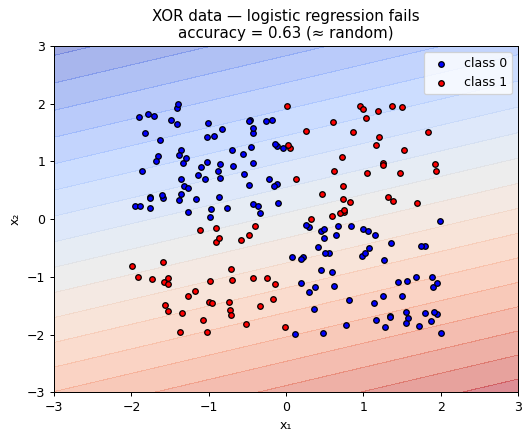

In [16]:
# Generate XOR-like data.
n_xor = 200
X_xor = rng.uniform(-2, 2, size=(n_xor, 2))
y_xor = ((X_xor[:, 0] * X_xor[:, 1]) > 0).astype(int)

lr_xor = SklearnLR().fit(X_xor, y_xor)
acc_xor = acc_score(y_xor, lr_xor.predict(X_xor))

xx_xor, yy_xor = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
P_xor = lr_xor.predict_proba(np.c_[xx_xor.ravel(), yy_xor.ravel()])[:, 1].reshape(
    xx_xor.shape
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx_xor, yy_xor, P_xor, levels=20, cmap="coolwarm", alpha=0.5)
ax.contour(xx_xor, yy_xor, P_xor, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c="blue", edgecolor="k",
           s=20, label="class 0")
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c="red", edgecolor="k",
           s=20, label="class 1")
ax.set_title(f"XOR data — logistic regression fails\naccuracy = {acc_xor:.2f} (≈ random)")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.legend()
plt.tight_layout()
plt.show()

**Reading.** XOR data requires a non-linear boundary. Logistic regression's single
hyperplane achieves ~50% accuracy — no better than random. Cure: add polynomial features
(e.g. $x_1 x_2$) or use a non-linear model (trees, neural networks).

### 6.6 Regularisation effect

/home/hien/Study/AI/Machine-Learning-from-scratch/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/hien/Study/AI/Machine-Learning-from-scratch/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty

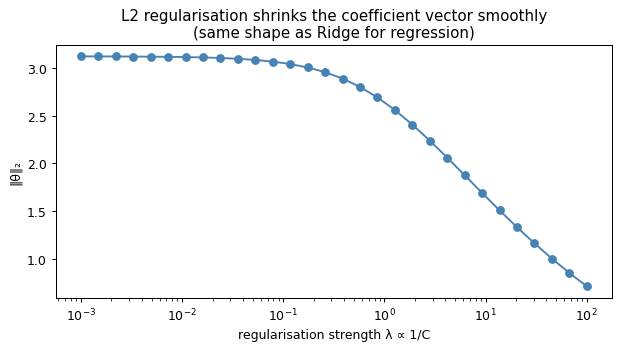

In [17]:
# Sweep C (inverse regularisation strength) and plot coefficient norm.
Cs = np.logspace(-2, 3, 30)
coef_norms = []
for C in Cs:
    m = SklearnLR(penalty="l2", C=C, solver="lbfgs").fit(X_2d, y_2d)
    coef_norms.append(np.linalg.norm(m.coef_))

plt.figure(figsize=(7, 4))
plt.plot(1 / Cs, coef_norms, "o-", color="steelblue")
plt.xscale("log")
plt.xlabel("regularisation strength λ ∝ 1/C")
plt.ylabel("‖θ‖₂")
plt.title("L2 regularisation shrinks the coefficient vector smoothly\n"
          "(same shape as Ridge for regression)")
plt.tight_layout()
plt.show()

**Reading.** As $\lambda$ grows, $\|\theta\|_2$ shrinks smoothly toward zero — same
monotone shrinkage as Ridge regression. With L1 instead, individual coefficients would
hit zero exactly (Lasso-like sparsity).

## 7. Connections

- **Smallest neural network.** Logistic regression is exactly one linear layer → sigmoid
  activation → output. Stack two of these and you have a 2-layer MLP. The training
  algorithm (gradient descent on cross-entropy) is the *same* used for all deep networks.
- **Ridge / Lasso.** Same penalty terms ($\lambda \|\theta\|_2^2$ or $\lambda \|\theta\|_1$),
  same Bayesian interpretation (Normal / Laplace prior), only the data term changes from
  squared error to cross-entropy.
- **SVM.** Same margin concept ($y' z$), different loss: smooth $\log(1 + e^{-y'z})$
  (logistic) vs kinked $\max(0, 1 - y'z)$ (hinge).
- **GLM framework.** IRLS generalises to Poisson, gamma, and any exponential family by
  varying the weight matrix $W$ and working response.

**Related topics:**
- [Gradient Descent](../02_gradient_descent/README.md)
- [Loss Functions](../../synthesis/loss_functions_map.md)

**Next:** Decision trees — a completely different model family with non-differentiable
splits and recursive partitioning.

## Takeaway

- **Binary logistic regression in ~60 lines.** Two solvers — GD (sub-linear) and
  Newton/IRLS (quadratic convergence) — both following the derivations from theory.md.
- **Cross-check.** Coefficients match sklearn to ~1e-8 on both unregularised and L2.
- **Softmax regression.** Same recipe with softmax + one-hot cross-entropy. Matches
  sklearn on iris.
- **Breast cancer pipeline.** Standardise → L2 fit → AUC > 0.99 → calibrated
  probabilities → cost-tuned threshold $\tau = 0.1$ for medical context.
- **Failure case.** XOR data is not linearly separable — logistic regression cannot
  learn it without feature engineering.
- **Numerical care.** Use stable sigmoid and `log1pexp` — naive implementations
  overflow/underflow at moderate $|z|$.